# 04 - Train + evaluate the regression models

We compare four candidates: two cheap interpretable **linear baselines** (alpha-tuned Lasso + Ridge) and two **gradient-boosting** models (sklearn HistGradientBoosting + LightGBM), all with a Poisson objective for the count targets.

The production models use gradient boosting:

* Cases model — HistGradientBoostingRegressor(loss="poisson") on `all_cause_cases`.
* Deaths model — HistGradientBoostingRegressor(loss="poisson") on `all_cause_deaths`.

**Temporal split:**
* train: `year <= 2018`
* **primary test: `year == 2019`** — the last clean pre-COVID year. This is the headline evaluation (`metrics.json["overall"]`), because it measures in-distribution forecasting quality.
* stress test: `year >= 2020` — the COVID era is a large out-of-distribution shock (weekly counts swing far outside anything in the training years). We still report it, separately, as a robustness check (`metrics.json["stress_2020plus"]`), but it is *not* the headline metric.

Hyperparameters are tuned with `TimeSeriesSplit(n_splits=5)` inside `GridSearchCV` on the training years (shared by the Lasso, Ridge, HGBR, and LightGBM searches). All four candidates are compared head-to-head on MAE and R² in section 5.

Outputs (in `data/output/models/`):
* `cases_hgbr.joblib`, `deaths_hgbr.joblib` — only the HGBR models are persisted (the Streamlit UI + notebook 05 use SHAP `TreeExplainer`, which needs a tree model); the Lasso/Ridge/LightGBM fits are experimentation only.
* `feature_columns.json` (already written by `03-feature-engineering`; we also persist the trained-model column order to avoid drift)
* `metrics.json` — overall (2019) + stress (2020+) + per-city test metrics for display in the Streamlit UI
* `importance_cases.csv`, `importance_deaths.csv` — permutation feature importance ranking

In [1]:
import json
import sys
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_poisson_deviance
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer

warnings.filterwarnings("ignore", category=UserWarning)

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent

PROC_DIR = REPO_ROOT / "data" / "processed"
OUT_DIR = REPO_ROOT / "data" / "output" / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC_DIR / "regression_modeling_table.csv", parse_dates=["date"])
feature_cols = json.loads((PROC_DIR / "feature_columns.json").read_text())
print("modelling table:", df.shape)
print("# feature cols  :", len(feature_cols))

modelling table: (10656, 229)
# feature cols  : 223


## 1. Temporal split

Drop rows where the lag features are NaN (first 4 weeks of each city). Then split on `year`:

* **train** — `year <= 2018`
* **test (primary)** — `year == 2019`, the last clean pre-COVID year; the headline evaluation.
* **stress (2020+)** — the COVID era, held out and reported separately as a robustness check (it is a large distribution shift, not representative of normal-season forecasting).

In [2]:
lag_cols = [c for c in feature_cols if c.startswith(("all_cause_cases_lag", "all_cause_deaths_lag"))]
n0 = len(df)
df = df.dropna(subset=lag_cols).reset_index(drop=True)
print(f"dropped {n0 - len(df)} rows with NaN lag features (first 4 weeks of each city)")

df["year"] = df["date"].dt.year
train  = df[df["year"] <= 2018]
test   = df[df["year"] == 2019]   # primary held-out test: last clean pre-COVID year
stress = df[df["year"] >= 2020]   # COVID-era stress test, reported separately
print("train:", train.shape, "test(2019):", test.shape, "stress(2020+):", stress.shape)

X_train  = train[feature_cols]
X_test   = test[feature_cols]
X_stress = stress[feature_cols]
y_train_cases   = train["all_cause_cases"].astype(float)
y_train_deaths  = train["all_cause_deaths"].astype(float)
y_test_cases    = test["all_cause_cases"].astype(float)
y_test_deaths   = test["all_cause_deaths"].astype(float)
y_stress_cases  = stress["all_cause_cases"].astype(float)
y_stress_deaths = stress["all_cause_deaths"].astype(float)

dropped 48 rows with NaN lag features (first 4 weeks of each city)
train: (8112, 229) test(2019): (624, 229) stress(2020+): (1872, 229)


## 2. Linear baselines (Lasso + Ridge)

Linear models need two things HGBR handles natively:

* **NaN imputation** — after dropping the lag-NaN rows, some feature columns still carry NaNs (notebook 03 keeps columns up to 50% NaN). `SimpleImputer(strategy="median")` fills them.
* **Feature scaling** — `StandardScaler` puts every feature on unit variance so the L1/L2 penalties are meaningful.

Each model is a `Pipeline`. Both Lasso and Ridge alphas are tuned with `TimeSeriesSplit(n_splits=5)` inside `GridSearchCV`. Lasso (L1) encourages sparsity — many coefficients will go to exactly zero — making it a natural feature-selector. Ridge (L2) shrinks all coefficients smoothly and tends to be more stable with correlated features. Both are **baselines only** — HGBR remains the persisted production model (the Streamlit UI + notebook 05 rely on SHAP `TreeExplainer`, which needs a tree model).

In [3]:
def _inf_to_nan(a):
    """Map +/-inf to NaN. Some features (e.g. the SPI climate index) go infinite when
    precipitation is zero; SimpleImputer only fills NaN, so we convert inf first.
    Named (not a lambda) so the pipeline pickles cleanly under GridSearchCV(n_jobs=-1)."""
    return np.where(np.isinf(a), np.nan, a)

def fit_linear(X, y, kind):
    """Fit a inf-clean -> impute -> scale -> linear-model pipeline.
    kind='lasso' -> alpha-tuned L1; kind='ridge' -> alpha-tuned L2."""
    pre = [FunctionTransformer(_inf_to_nan), SimpleImputer(strategy="median"), StandardScaler()]
    if kind == "lasso":
        base = make_pipeline(*pre, Lasso(max_iter=10_000))
        grid = GridSearchCV(
            base,
            {"lasso__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
            cv=TimeSeriesSplit(n_splits=5),
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
        )
        grid.fit(X, y)
        print("  best lasso alpha:", grid.best_params_["lasso__alpha"])
        return grid.best_estimator_
    base = make_pipeline(*pre, Ridge())
    grid = GridSearchCV(
        base,
        {"ridge__alpha": [0.1, 1.0, 10.0, 100.0, 1000.0]},
        cv=TimeSeriesSplit(n_splits=5),
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    grid.fit(X, y)
    print("  best ridge alpha:", grid.best_params_["ridge__alpha"])
    return grid.best_estimator_

print("fitting linear baselines (cases)...")
lasso_cases  = fit_linear(X_train, y_train_cases,  "lasso")
ridge_cases  = fit_linear(X_train, y_train_cases,  "ridge")
print("fitting linear baselines (deaths)...")
lasso_deaths = fit_linear(X_train, y_train_deaths, "lasso")
ridge_deaths = fit_linear(X_train, y_train_deaths, "ridge")

fitting linear baselines (cases)...


  best lasso alpha: 1.0


  best ridge alpha: 1000.0
fitting linear baselines (deaths)...


  best lasso alpha: 1.0


  best ridge alpha: 1000.0


## 3. GridSearchCV (TimeSeriesSplit) on the cases model

In [4]:
PARAM_GRID = {
    "max_iter":        [200, 500],
    "learning_rate":   [0.05, 0.1],
    "max_depth":       [None, 6, 10],
    "min_samples_leaf":[20, 50],
}

def fit_grid(X, y, loss):
    base = HistGradientBoostingRegressor(loss=loss, random_state=42)
    grid = GridSearchCV(
        base,
        PARAM_GRID,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
        verbose=0,
    )
    grid.fit(X, y)
    return grid

print("fitting cases model...")
cases_grid = fit_grid(X_train, y_train_cases, loss="poisson")
print("best params:", cases_grid.best_params_)
print("best CV score (neg MAE):", cases_grid.best_score_)

fitting cases model...


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


...

/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


best params: {'learning_rate': 0.05, 'max_depth': 6, 'max_iter': 200, 'min_samples_leaf': 50}
best CV score (neg MAE): -18.396487723178826


In [5]:
print("fitting deaths model...")
deaths_grid = fit_grid(X_train, y_train_deaths, loss="poisson")
print("best params:", deaths_grid.best_params_)
print("best CV score (neg MAE):", deaths_grid.best_score_)

fitting deaths model...


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


...

/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


/Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


best params: {'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 200, 'min_samples_leaf': 50}
best CV score (neg MAE): -6.983585735931227


## 3b. LightGBM (Poisson)

LightGBM is a second gradient-boosting candidate. Like HGBR it handles NaNs natively and uses a Poisson objective for the count target, but its leaf-wise growth + histogram binning often edges out sklearn's HGBR on tabular data. Tuned over the same `TimeSeriesSplit(n_splits=5)` CV. This is an **exploration** model — HGBR remains the persisted production model (notebook 05 + the Streamlit UI build their SHAP `TreeExplainer` against the HGBR joblibs).

In [6]:
LGB_PARAM_GRID = {
    "n_estimators":      [300, 600],
    "learning_rate":     [0.05, 0.1],
    "num_leaves":        [31, 63],
    "min_child_samples": [20, 50],
}

def fit_lgb(X, y):
    # n_jobs=1 on the estimator so the GridSearchCV fold-parallelism (n_jobs=-1) does not
    # oversubscribe the cores with LightGBM's own threads.
    base = LGBMRegressor(objective="poisson", random_state=42, n_jobs=1, verbose=-1)
    grid = GridSearchCV(
        base,
        LGB_PARAM_GRID,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X, y)
    return grid

print("fitting LightGBM cases model...")
lgb_cases_grid = fit_lgb(X_train, y_train_cases)
print("best params:", lgb_cases_grid.best_params_)
print("best CV score (neg MAE):", lgb_cases_grid.best_score_)

print("fitting LightGBM deaths model...")
lgb_deaths_grid = fit_lgb(X_train, y_train_deaths)
print("best params:", lgb_deaths_grid.best_params_)
print("best CV score (neg MAE):", lgb_deaths_grid.best_score_)

lgb_cases  = lgb_cases_grid.best_estimator_
lgb_deaths = lgb_deaths_grid.best_estimator_

fitting LightGBM cases model...


best params: {'learning_rate': 0.05, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31}
best CV score (neg MAE): -18.57201523994778
fitting LightGBM deaths model...


best params: {'learning_rate': 0.05, 'min_child_samples': 20, 'n_estimators': 600, 'num_leaves': 31}
best CV score (neg MAE): -6.780493913180147


## 4. Evaluate on the held-out test sets

The **primary** evaluation is the 2019 test set (clean pre-COVID year): overall MAE, RMSE, R², and Poisson deviance for all four candidates (HGBR, LightGBM, lasso, ridge). The 2020+ **stress test** follows in its own cell — same metrics, COVID-era data — so you can see how far each model degrades under the distribution shift without letting it dominate the headline numbers. Per-city MAE/R² for the production HGBR models (on the 2019 test set) come after.

In [7]:
def safe_poisson_dev(y_true, y_pred):
    # mean_poisson_deviance requires y_pred > 0; clip tiny negatives from numerical noise
    # (also clips the genuinely negative predictions Lasso/Ridge can produce on a count target).
    return float(mean_poisson_deviance(y_true, np.maximum(y_pred, 1e-6)))

def metrics_row(label, y_true, y_pred):
    return {
        "label": label,
        "mae":         float(mean_absolute_error(y_true, y_pred)),
        "rmse":        float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2":          float(r2_score(y_true, y_pred)),
        "poisson_dev": safe_poisson_dev(y_true, y_pred),
        "n":           int(len(y_true)),
    }

def eval_block(X, y_cases, y_deaths):
    """All four candidates' metrics rows on one (X, y) split."""
    return [
        metrics_row("cases / HGBR",     y_cases.values,  cases_grid.predict(X)),
        metrics_row("cases / lightgbm", y_cases.values,  lgb_cases.predict(X)),
        metrics_row("cases / lasso",    y_cases.values,  lasso_cases.predict(X)),
        metrics_row("cases / ridge",    y_cases.values,  ridge_cases.predict(X)),
        metrics_row("deaths / HGBR",     y_deaths.values, deaths_grid.predict(X)),
        metrics_row("deaths / lightgbm", y_deaths.values, lgb_deaths.predict(X)),
        metrics_row("deaths / lasso",    y_deaths.values, lasso_deaths.predict(X)),
        metrics_row("deaths / ridge",    y_deaths.values, ridge_deaths.predict(X)),
    ]

# HGBR production-model preds on the primary (2019) test set, reused by the per-city table below.
pred_cases  = cases_grid.predict(X_test)
pred_deaths = deaths_grid.predict(X_test)

# --- primary evaluation: 2019 test set ---
rows = eval_block(X_test, y_test_cases, y_test_deaths)
metrics_df = pd.DataFrame(rows)
print("Primary test set: 2019 (clean pre-COVID year)")
metrics_df

Primary test set: 2019 (clean pre-COVID year)


,label,mae,rmse,r2,poisson_dev,n
0,cases / HGBR,34.906829,143.027179,0.553557,36.095680,624
1,cases / lightgbm,34.519333,144.310031,0.545513,36.021101,624
2,cases / lasso,40.856411,145.398523,0.538631,40.348138,624
3,cases / ridge,39.260426,146.226822,0.533359,43.846378,624
4,deaths / HGBR,4.604752,6.362741,0.823870,1.925495,624
5,deaths / lightgbm,4.563586,6.324156,0.826000,1.916349,624
6,deaths / lasso,5.128845,6.978213,0.788148,2.549765,624
7,deaths / ridge,4.398643,6.063516,0.840046,1.769267,624


In [8]:
# --- stress test: 2020+ (COVID era, out-of-distribution) ---
# Reported separately from the headline 2019 numbers. Expect every model to degrade here;
# the point is *how much*, not to pick a winner.
stress_rows = eval_block(X_stress, y_stress_cases, y_stress_deaths)
stress_df = pd.DataFrame(stress_rows)
print("Stress test: 2020+ (COVID era — robustness check, not the headline metric)")
stress_df

Stress test: 2020+ (COVID era — robustness check, not the headline metric)


,label,mae,rmse,r2,poisson_dev,n
0,cases / HGBR,9.924312,20.604814,0.529233,9.518199,1872
1,cases / lightgbm,10.891034,22.857940,0.420648,13.668645,1872
2,cases / lasso,10.823011,18.115424,0.636114,11.945978,1872
3,cases / ridge,14.908117,22.008820,0.462891,41.424678,1872
4,deaths / HGBR,10.766164,16.515214,0.312931,15.600885,1872
5,deaths / lightgbm,10.797788,20.830079,-0.092983,52.327005,1872
6,deaths / lasso,8.537458,11.902076,0.643157,10.368358,1872
7,deaths / ridge,12.508850,17.288511,0.247083,18.038916,1872


In [9]:
# Per-city MAE and R² for the production HGBR models, on the primary (2019) test set.
per_city = test.assign(pred_cases=pred_cases, pred_deaths=pred_deaths).groupby("adm3_pcode").apply(
    lambda g: pd.Series({
        "n":          int(len(g)),
        "cases_mae":  float(mean_absolute_error(g["all_cause_cases"],  g["pred_cases"])),
        "cases_r2":   float(r2_score(g["all_cause_cases"],  g["pred_cases"])),
        "deaths_mae": float(mean_absolute_error(g["all_cause_deaths"], g["pred_deaths"])),
        "deaths_r2":  float(r2_score(g["all_cause_deaths"], g["pred_deaths"])),
    }),
    include_groups=False,
).reset_index()
per_city

/tmp/claude-1275385993/ipykernel_27852/282851294.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  per_city = test.assign(pred_cases=pred_cases, pred_deaths=pred_deaths).groupby("adm3_pcode").apply(
/tmp/claude-1275385993/ipykernel_27852/282851294.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  per_city = test.assign(pred_cases=pred_cases, pred_deaths=pred_deaths).groupby("adm3_pcode").apply(


,adm3_pcode,n,cases_mae,cases_r2,deaths_mae,deaths_r2
0,PH015518000,52.0,5.751407,0.290287,5.582885,-0.166993
1,PH034919000,52.0,2.931189,0.118780,0.757920,-0.044198
2,PH050506000,52.0,3.102109,0.431260,3.053811,-0.193278
3,PH063022000,52.0,249.557033,0.343843,4.371972,-0.160045
4,PH072230000,52.0,8.842185,0.307999,2.942770,-0.080765
5,PH083747000,52.0,30.832421,0.232849,3.409978,-0.172359
6,PH097332000,52.0,51.535470,0.440547,9.346511,-0.427483
7,PH104305000,52.0,17.979960,0.777722,5.386337,0.221102
8,PH112402000,52.0,23.268999,0.725026,6.963413,-0.401674
9,PH137401000,52.0,7.236056,0.186256,4.743601,-1.800381


## 5. Model comparison

Two figures, one per test period — the **2019 headline** and the **2020+ COVID stress test** — kept separate so the in-distribution result is never visually mixed with the shock. Within each figure there are two panels (MAE, lower = better; R², higher = better), and each model shows a pair of bars: **blue = cases, red = deaths**.

R² is unit-free, so the cases-vs-deaths bars are directly comparable; MAE is in raw weekly counts, so the cases bars sit on a much larger scale than deaths (cases volumes are higher). The printed tables above give the exact 2019-vs-2020+ numbers including RMSE and Poisson deviance.


=== cases: 2019 (headline) vs 2020+ (stress) ===


,mae_2019,rmse_2019,r2_2019,poisson_dev_2019,mae_2020+,rmse_2020+,r2_2020+,poisson_dev_2020+
model,,,,,,,,
HGBR,34.907,143.027,0.554,36.096,9.924,20.605,0.529,9.518
lightgbm,34.519,144.310,0.546,36.021,10.891,22.858,0.421,13.669
lasso,40.856,145.399,0.539,40.348,10.823,18.115,0.636,11.946
ridge,39.260,146.227,0.533,43.846,14.908,22.009,0.463,41.425



=== deaths: 2019 (headline) vs 2020+ (stress) ===


,mae_2019,rmse_2019,r2_2019,poisson_dev_2019,mae_2020+,rmse_2020+,r2_2020+,poisson_dev_2020+
model,,,,,,,,
HGBR,4.605,6.363,0.824,1.925,10.766,16.515,0.313,15.601
lightgbm,4.564,6.324,0.826,1.916,10.798,20.830,-0.093,52.327
lasso,5.129,6.978,0.788,2.550,8.537,11.902,0.643,10.368
ridge,4.399,6.064,0.840,1.769,12.509,17.289,0.247,18.039


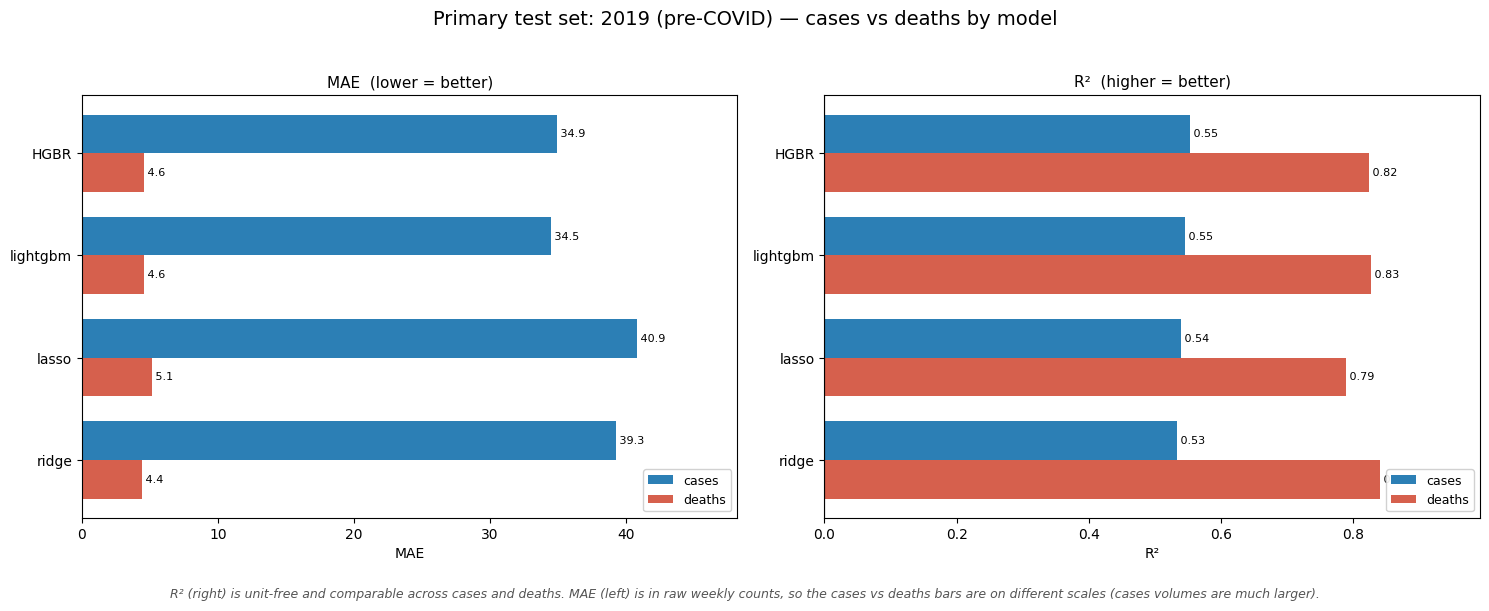

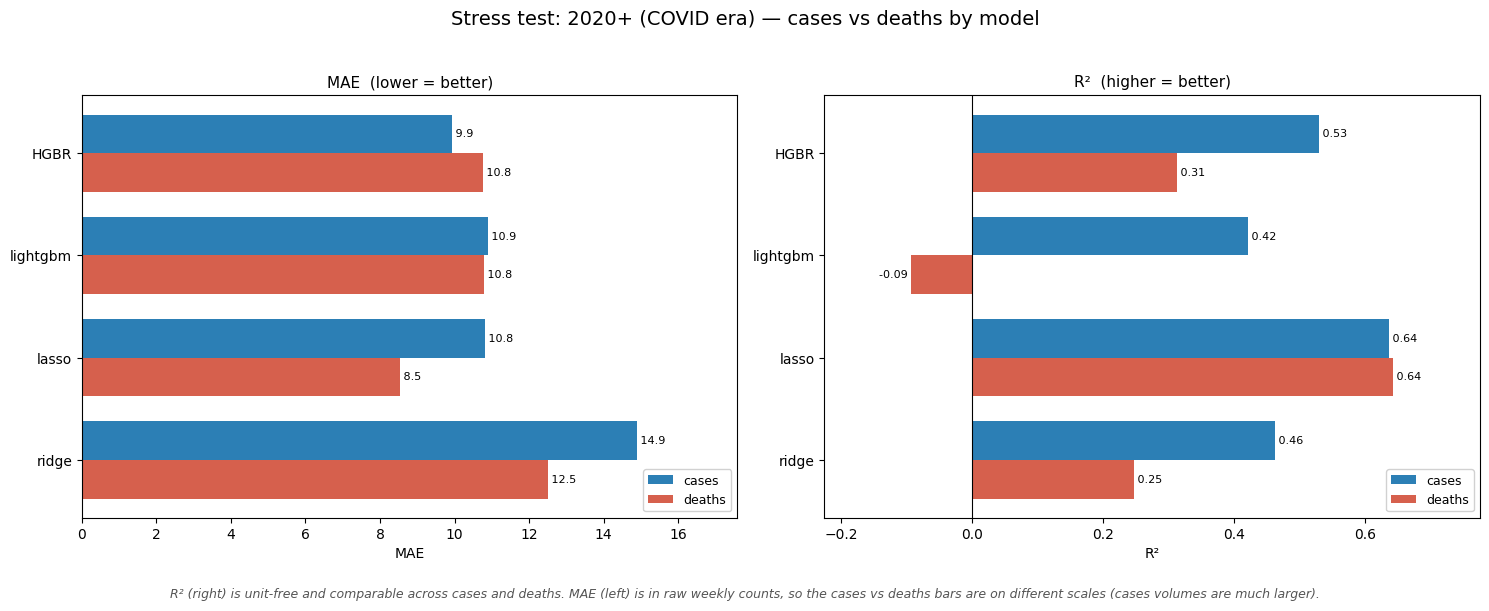

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def _split(d):
    d = d.copy()
    d[["outcome", "model"]] = d["label"].str.split(" / ", expand=True)
    return d

MODEL_ORDER = ["HGBR", "lightgbm", "lasso", "ridge"]  # fixed order so panels line up
C_CASES, C_DEATHS = "#2c7fb5", "#d6604d"
y = np.arange(len(MODEL_ORDER))
bar_h = 0.38

def annotate(ax, ys, vals, fmt):
    for yi, v in zip(ys, vals):
        if v >= 0:
            ax.text(v, yi, " " + fmt.format(v), va="center", ha="left", fontsize=8)
        else:
            ax.text(v, yi, fmt.format(v) + " ", va="center", ha="right", fontsize=8)

def plot_period(mdf, period_label):
    """One figure per test period: MAE and R² panels, grouped bars = cases vs deaths per model."""
    d = _split(mdf)
    cases  = d[d["outcome"] == "cases"].set_index("model").loc[MODEL_ORDER]
    deaths = d[d["outcome"] == "deaths"].set_index("model").loc[MODEL_ORDER]
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, (metric, fmt, lower_better) in zip(axes, [("mae", "{:.1f}", True), ("r2", "{:.2f}", False)]):
        ax.barh(y - bar_h / 2, cases[metric],  height=bar_h, color=C_CASES,  label="cases")
        ax.barh(y + bar_h / 2, deaths[metric], height=bar_h, color=C_DEATHS, label="deaths")
        annotate(ax, y - bar_h / 2, cases[metric].values, fmt)
        annotate(ax, y + bar_h / 2, deaths[metric].values, fmt)
        ax.set_yticks(y)
        ax.set_yticklabels(MODEL_ORDER)
        ax.invert_yaxis()
        ax.margins(x=0.18)
        metric_lbl = "R²" if metric == "r2" else "MAE"
        direction = "lower = better" if lower_better else "higher = better"
        ax.set_title(f"{metric_lbl}  ({direction})", fontsize=11)
        ax.set_xlabel(metric_lbl)
        if metric == "r2":
            ax.axvline(0, color="black", linewidth=0.8)
        ax.legend(fontsize=9, loc="lower right", framealpha=0.9)
    fig.suptitle(period_label, fontsize=14, y=1.03)
    fig.text(0.5, -0.04,
             "R² (right) is unit-free and comparable across cases and deaths. MAE (left) is in raw weekly counts, "
             "so the cases vs deaths bars are on different scales (cases volumes are much larger).",
             ha="center", fontsize=9, style="italic", color="#555")
    plt.tight_layout()
    plt.show()

# --- printed side-by-side tables (2019 vs 2020+) ---
comp        = _split(metrics_df)
stress_comp = _split(stress_df)
for outcome in ["cases", "deaths"]:
    primary = comp[comp["outcome"] == outcome].set_index("model").loc[MODEL_ORDER, ["mae", "rmse", "r2", "poisson_dev"]]
    shock   = stress_comp[stress_comp["outcome"] == outcome].set_index("model").loc[MODEL_ORDER, ["mae", "rmse", "r2", "poisson_dev"]]
    merged = primary.join(shock, lsuffix="_2019", rsuffix="_2020+")
    print(f"\n=== {outcome}: 2019 (headline) vs 2020+ (stress) ===")
    display(merged.round(3))

# --- two separate figures, one per test period; bars within each are cases vs deaths ---
plot_period(metrics_df, "Primary test set: 2019 (pre-COVID) — cases vs deaths by model")
plot_period(stress_df,  "Stress test: 2020+ (COVID era) — cases vs deaths by model")

## 6. Linear model coefficients (top-N features)

The linear analog of the HGBR permutation/SHAP importance. Because every feature is standardized to unit variance inside the pipeline, the Lasso/Ridge coefficients are directly comparable: `|coef|` ranks how strongly each feature drives the prediction, and the sign shows the direction of the association. Lasso's L1 penalty will zero out many features entirely, exposing a sparse set of predictors; Ridge's L2 penalty retains all features but shrinks the less-informative ones. These rankings are for interpretation only — they are **not persisted** (the Streamlit UI sliders come from the HGBR SHAP shortlist in notebook 05).


=== top 15 ridge / cases (by |standardized coef|) ===


,feature,coef
204,all_cause_cases_lag4wk,36.074067
206,year,5.619382
210,week_cos,-5.202329
19,pr_norm,4.856953
2,so2,-3.158156
77,dentist_nearest,3.041363
12,rh,-2.986948
37,avg_rad_std,2.784261
59,park_nearest,-2.560734
207,month,-2.269594



=== top 15 ridge / deaths (by |standardized coef|) ===


,feature,coef
205,all_cause_deaths_lag4wk,1.564210
206,year,1.336899
72,university_count,0.835107
53,kindergarten_nearest,0.689237
23,pop_count_total,0.629985
204,all_cause_cases_lag4wk,0.540336
90,water_tower_count,0.525511
87,drinking_water_nearest,0.470824
37,avg_rad_std,0.466882
115,osm_drain_nearest,-0.397225



=== top 15 lasso / cases (by |standardized coef|) ===


,feature,coef
204,all_cause_cases_lag4wk,44.160090
169,doh_pois_count,5.418023
210,week_cos,-3.454360
19,pr_norm,2.321014
207,month,-1.434826
206,year,1.101969
214,city_PH063022000,0.960456
14,uv_rad,-0.624618
123,pct_area_shrubland,0.581465
9,heat_index,-0.558669



=== top 15 lasso / deaths (by |standardized coef|) ===


,feature,coef
205,all_cause_deaths_lag4wk,4.846407
169,doh_pois_count,2.330229
23,pop_count_total,1.627052
72,university_count,0.554215
66,supermarket_count,0.329935
206,year,0.320406
98,toilet_count,0.069904
174,doh_hospital_count,0.043210
176,doh_birthing_home_lying_in_clinic_count,0.040499
147,google_bldgs_pct_built_up_area,0.000000


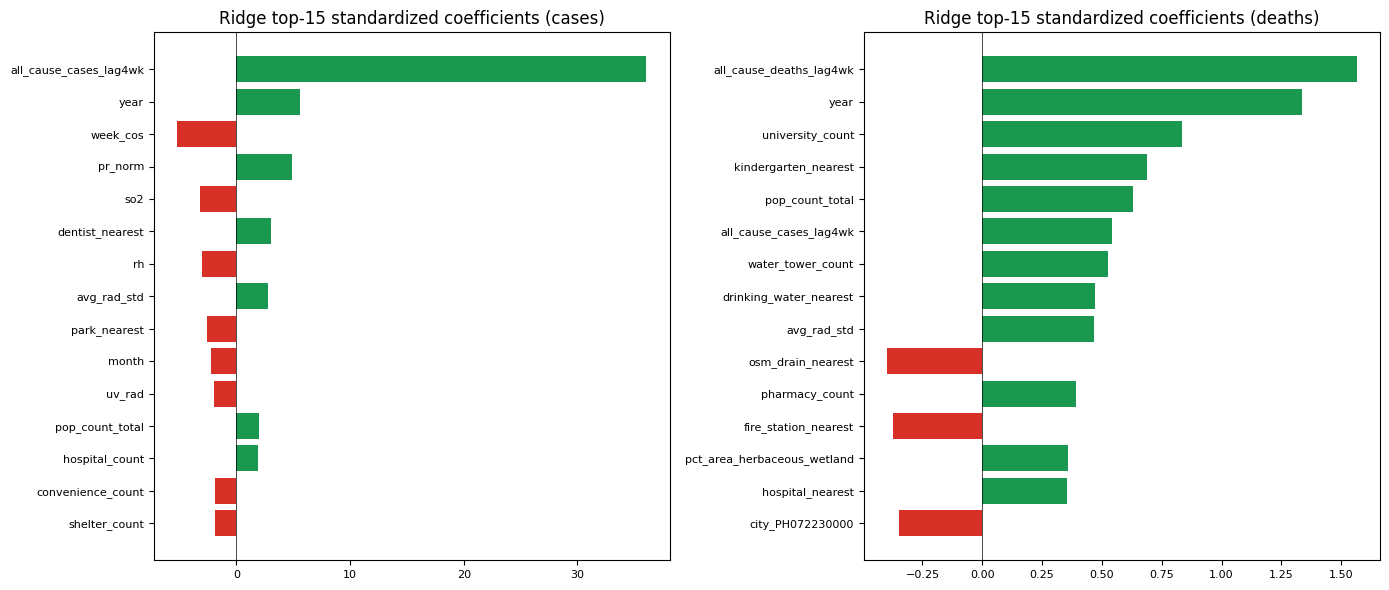

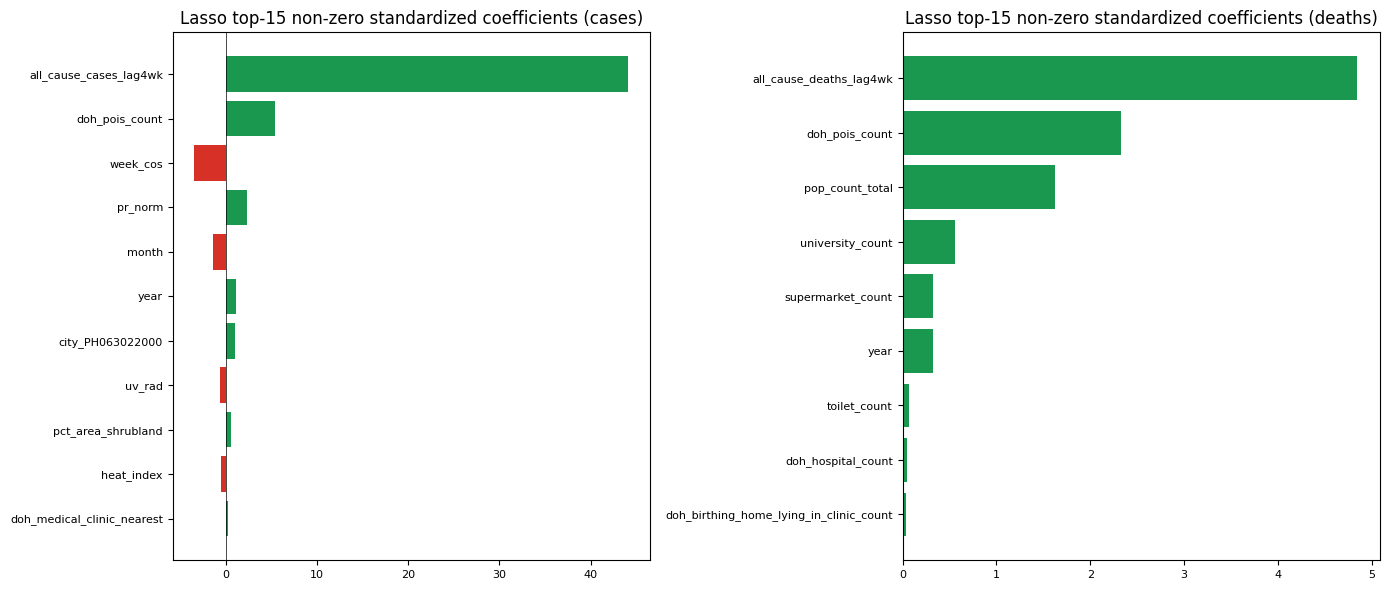

In [11]:
def top_linear_coefs(pipeline, step_name, label, top_n=15):
    """Rank features by |standardized coefficient| for a fitted linear pipeline."""
    coefs = pipeline.named_steps[step_name].coef_
    imp = (
        pd.DataFrame({"feature": feature_cols, "coef": coefs})
        .assign(abs_coef=lambda d: d["coef"].abs())
        .sort_values("abs_coef", ascending=False)
        .head(top_n)
    )
    print(f"\n=== top {top_n} {label} (by |standardized coef|) ===")
    display(imp[["feature", "coef"]])
    return imp

ridge_top_cases  = top_linear_coefs(ridge_cases,  "ridge", "ridge / cases")
ridge_top_deaths = top_linear_coefs(ridge_deaths, "ridge", "ridge / deaths")
lasso_top_cases  = top_linear_coefs(lasso_cases,  "lasso", "lasso / cases")
lasso_top_deaths = top_linear_coefs(lasso_deaths, "lasso", "lasso / deaths")

# Signed-coefficient bar charts for the ridge models (L2 is more stable than L1 across the full feature set).
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, imp, label in zip(axes, [ridge_top_cases, ridge_top_deaths], ["cases", "deaths"]):
    d = imp.iloc[::-1]
    ax.barh(d["feature"], d["coef"], color=["#1a9850" if v > 0 else "#d73027" for v in d["coef"]])
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"Ridge top-15 standardized coefficients ({label})")
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# Lasso bar charts (L1 — many coefficients will be exactly zero; only non-zero shown).
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, imp, label in zip(axes, [lasso_top_cases, lasso_top_deaths], ["cases", "deaths"]):
    d = imp[imp["coef"] != 0].iloc[::-1]
    if d.empty:
        ax.set_title(f"Lasso ({label}) — all coefficients zeroed out")
        continue
    ax.barh(d["feature"], d["coef"], color=["#1a9850" if v > 0 else "#d73027" for v in d["coef"]])
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"Lasso top-15 non-zero standardized coefficients ({label})")
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

## 7. Persist artifacts for the Streamlit UI

In [12]:
joblib.dump(cases_grid.best_estimator_,  OUT_DIR / "cases_hgbr.joblib")
joblib.dump(deaths_grid.best_estimator_, OUT_DIR / "deaths_hgbr.joblib")
(OUT_DIR / "feature_columns.json").write_text(json.dumps(feature_cols, indent=2))

metrics_payload = {
    "overall": rows,                  # primary test set: 2019 (pre-COVID) — the headline metrics
    "stress_2020plus": stress_rows,   # COVID-era stress test, reported separately
    "per_city": per_city.to_dict(orient="records"),  # HGBR, 2019 test set
    "best_params": {"cases": cases_grid.best_params_, "deaths": deaths_grid.best_params_},
}
(OUT_DIR / "metrics.json").write_text(json.dumps(metrics_payload, indent=2, default=str))
print("wrote:", *(p.name for p in OUT_DIR.iterdir()))

wrote: metrics.json shap_importance_cases.csv importance_cases.csv deaths_hgbr.joblib feature_columns.json top_features_cases.json top_features_deaths.json cases_hgbr.joblib importance_deaths.csv shap_importance_deaths.csv


## 8. Global feature importance via permutation

We use sklearn `permutation_importance` rather than SHAP at this stage because it works on the test set and is cheap; the heavier per-row SHAP attribution lives in `05-analyze` + the Streamlit UI's local explanations.

In [13]:
from sklearn.inspection import permutation_importance

def importance(model, X, y, label):
    r = permutation_importance(model, X, y, n_repeats=5, random_state=42, n_jobs=-1)
    imp = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": r.importances_mean,
        "importance_std":  r.importances_std,
    }).sort_values("importance_mean", ascending=False)
    out = OUT_DIR / f"importance_{label}.csv"
    imp.to_csv(out, index=False)
    print("wrote", out)
    return imp.head(15)

print("top features driving cases predictions:")
display(importance(cases_grid.best_estimator_, X_test, y_test_cases, "cases"))
print("\ntop features driving deaths predictions:")
display(importance(deaths_grid.best_estimator_, X_test, y_test_deaths, "deaths"))

top features driving cases predictions:


wrote /Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/data/output/models/importance_cases.csv


,feature,importance_mean,importance_std
204,all_cause_cases_lag4wk,0.558763,0.034395
210,week_cos,0.209295,0.028771
19,pr_norm,0.192969,0.029949
23,pop_count_total,0.073633,0.021683
18,ndvi,0.048000,0.011165
34,avg_rad_min,0.031962,0.014494
50,fire_station_count,0.026134,0.015298
140,google_bldgs_count,0.021983,0.004237
209,week_sin,0.017061,0.010538
1,co,0.014264,0.004273



top features driving deaths predictions:


wrote /Users/adonaisray.maclang/Desktop/morbidity-mortality-modelling/data/output/models/importance_deaths.csv


,feature,importance_mean,importance_std
23,pop_count_total,0.702817,0.053588
140,google_bldgs_count,0.129643,0.008225
205,all_cause_deaths_lag4wk,0.097426,0.004552
204,all_cause_cases_lag4wk,0.017579,0.001605
34,avg_rad_min,0.014841,0.002190
31,pop_density_stdev,0.014144,0.004131
67,supermarket_nearest,0.013278,0.001909
60,police_count,0.008045,0.001038
28,pop_count_max,0.007291,0.000836
41,atm_nearest,0.005732,0.000516
